# Análise Exploratória de Dados

Análise exploratória dos dados do projeto de detecção de fraude.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_style(style='whitegrid')
#pd.set_option('display.max_columns', None)

# Carregamento de Arquivos

1. Foram disponibilizados dois arquivos de treino para o modelo

In [11]:
# Definindo o caminho para os arquivos
DATA_PATH = rf'C:\Users\iscso\OneDrive\Área de Trabalho\Portfolio\Fraud_Detection\data\raw'

# Carregando os dados de transações
df_transaction = pd.read_csv(rf'{DATA_PATH}\train_transaction.csv')
df_identity = pd.read_csv(rf'{DATA_PATH}\train_identity.csv')


In [12]:
# Avaliando bases
display(df_transaction.head())
display(df_identity.head())

# Avaliando dimensões
print('dimensões transactions: ', df_transaction.shape, ' | dimensões identidade: ', df_identity.shape)

# Avaliando dimensões
display(df_transaction.describe())
display(df_identity.describe())

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


dimensões transactions:  (590540, 394)  | dimensões identidade:  (144233, 41)


,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.00000,82351.000000,82351.000000,82351.000000,82351.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,0.775874,721.741883,1375.783644,1014.622782,9.807015,59.16455,28.530903,55.352422,151.160542,100.700882
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,4.727971,6217.223583,11169.275702,7955.735482,243.861391,387.62948,274.576920,668.486833,1095.034387,814.946722
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,0.000000,0.000000,25.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,55.000000,160000.000000,160000.000000,160000.000000,55125.000000,55125.00000,55125.000000,104060.000000,104060.000000,104060.000000


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,1.442330e+05,144233.000000,140872.000000,66324.000000,66324.000000,136865.000000,136865.000000,5155.000000,5155.000000,74926.000000,...,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.236329e+06,-10.170502,174716.584708,0.060189,-0.058938,1.615585,-6.698710,13.285354,-38.600388,0.091023,...,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.788496e+05,14.347949,159651.816856,0.598231,0.701015,5.249856,16.491104,11.384207,26.084899,0.983842,...,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987004e+06,-100.000000,1.000000,-13.000000,-28.000000,-72.000000,-100.000000,-46.000000,-100.000000,-36.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.077142e+06,-10.000000,67992.000000,0.000000,0.000000,0.000000,-6.000000,5.000000,-48.000000,0.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.198818e+06,-5.000000,125800.500000,0.000000,0.000000,0.000000,0.000000,14.000000,-34.000000,0.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,3.392923e+06,-5.000000,228749.000000,0.000000,0.000000,1.000000,0.000000,22.000000,-23.000000,0.000000,...,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.577534e+06,0.000000,999595.000000,10.000000,0.000000,52.000000,0.000000,61.000000,0.000000,25.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


In [13]:
# Verificando a distribuição da variável alvo (isFraud)
fraud_counts = df_transaction['isFraud'].value_counts()
fraud_percentage = df_transaction['isFraud'].value_counts(normalize=True)

print('Contagem de transações fraudulentas:')
display(fraud_counts)
print('\nPercentual de transações fraudulentas:')
print(fraud_percentage)

Contagem de transações fraudulentas:


isFraud
0    569877
1     20663
Name: count, dtype: int64


Percentual de transações fraudulentas:
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


In [15]:
# Mesclando os dados de transações e identidade usando TransactionID como chave
df_full = df_transaction.merge(df_identity, on='TransactionID', how='left')

print(f'Dimensões dos dados mesclados: {df_full.shape}')
df_full.head()

Dimensões dos dados mesclados: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


Número de colunas com valores ausentes: 414


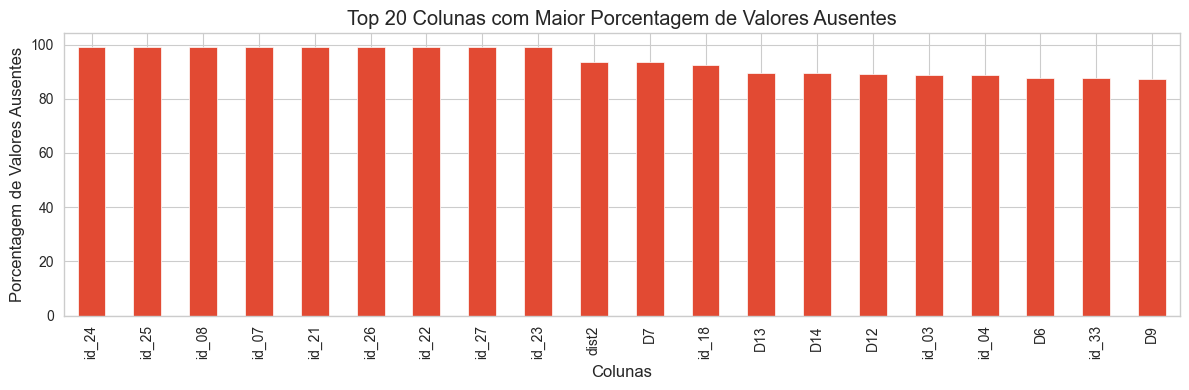

In [22]:
# Calculando a porcentagem de valores ausentes em cada coluna
missing_values = df_full.isnull().mean().sort_values(ascending=False) * 100

# Filtrando apenas colunas com valores ausentes
missing_values = missing_values[missing_values > 0]

print(f'Número de colunas com valores ausentes: {len(missing_values)}')

# Visualizando as 20 colunas com maior porcentagem de valores ausentes
plt.figure(figsize=(12, 4))
missing_values[:20].plot(kind='bar')
plt.title('Top 20 Colunas com Maior Porcentagem de Valores Ausentes')
plt.xlabel('Colunas')
plt.ylabel('Porcentagem de Valores Ausentes')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

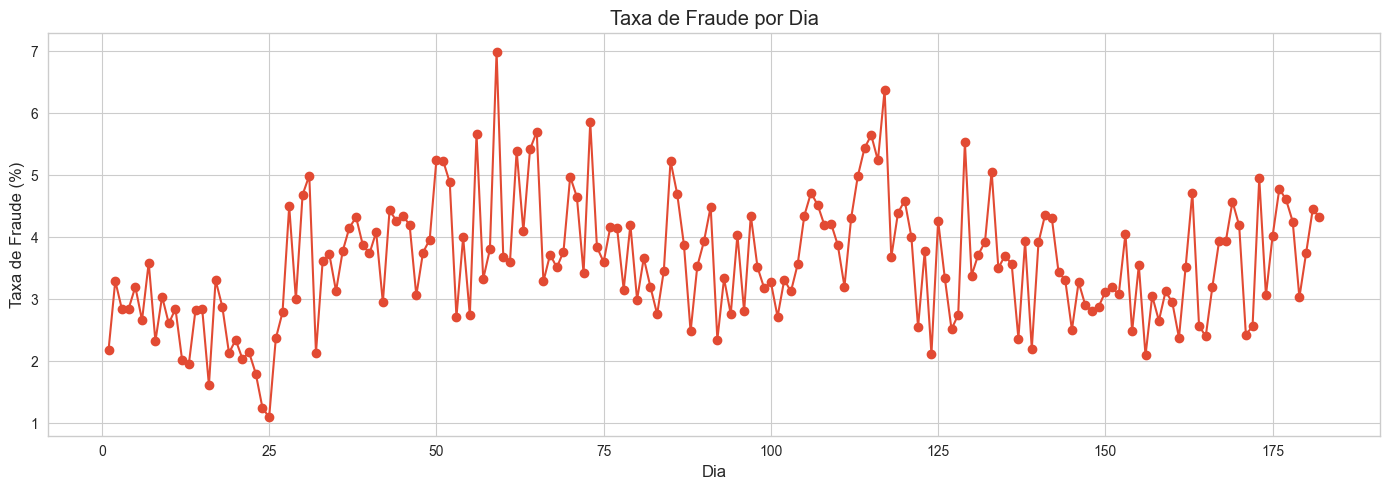

In [17]:
# Convertendo TransactionDT para dias
df_full['TransactionDay'] = df_full['TransactionDT'] // (24 * 60 * 60)

# Convertendo TransactionDT para horas do dia (0-23)
df_full['TransactionHour'] = (df_full['TransactionDT'] % (24 * 60 * 60)) // 3600

# Agrupando por dia e calculando a taxa de fraude
fraud_by_day = df_full.groupby('TransactionDay')['isFraud'].agg(['count', 'sum', 'mean'])
fraud_by_day.columns = ['total_transactions', 'total_frauds', 'fraud_rate']

# Agrupando por hora e calculando a taxa de fraude
fraud_by_hour = df_full.groupby('TransactionHour')['isFraud'].agg(['count', 'sum', 'mean'])
fraud_by_hour.columns = ['total_transactions', 'total_frauds', 'fraud_rate']

# Visualizando a taxa de fraude por dia
plt.figure(figsize=(14, 5))
plt.plot(fraud_by_day.index, fraud_by_day['fraud_rate'] * 100, marker='o', linestyle='-')
plt.title('Taxa de Fraude por Dia')
plt.xlabel('Dia')
plt.ylabel('Taxa de Fraude (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
fraud_by_hour

,total_transactions,total_frauds,fraud_rate
TransactionHour,,,
0,37795,1186,0.031380
1,32797,1027,0.031314
2,26732,1002,0.037483
3,20802,797,0.038314
4,14839,770,0.051890
5,9701,682,0.070302
6,6007,467,0.077743
7,3704,393,0.106102
8,2591,241,0.093014


In [77]:

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(x=fraud_by_hour.index, y=fraud_by_hour['total_transactions'], name='Total de Transações'),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(x=fraud_by_hour.index, y=fraud_by_hour['total_frauds'],
               mode='lines+markers', name='Taxa de Fraude (%)',
               line=dict(color='red')),
    secondary_y=True
)
fig.update_layout(
    title='Total de Transações vs. Total de Fraudes por Hora',
    xaxis_title='Hora do Dia',
    legend=dict(x=0.5, xanchor='center', y=-0.2, orientation='h'),
    height=450
)
fig.update_yaxes(title_text='Número de Transações', secondary_y=False)
fig.update_yaxes(title_text='Total de Fraudes', secondary_y=True)

fig.show()


In [26]:
# Estatísticas do valor das transações
df_full['TransactionAmt'].describe()

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

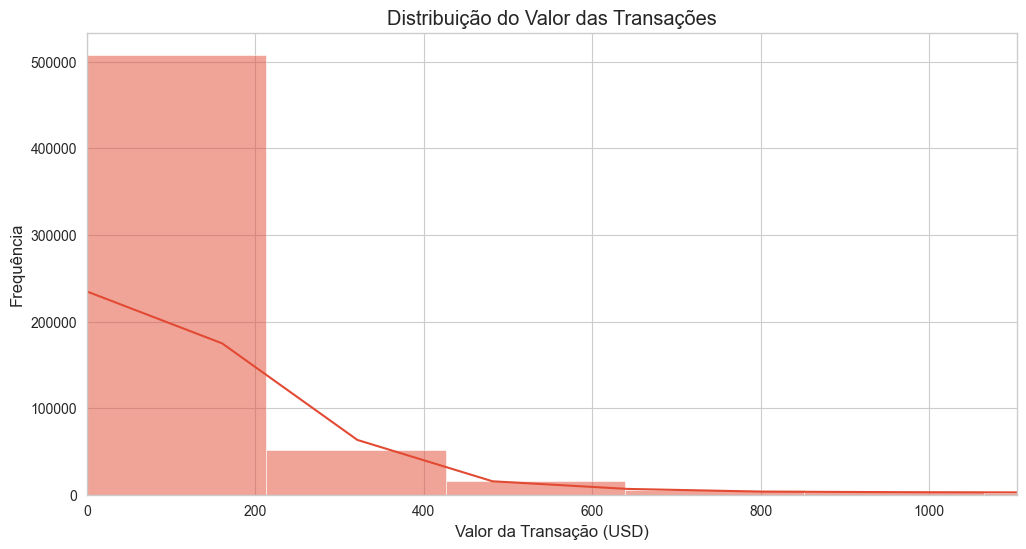

In [32]:
# Visualizando a distribuição do valor das transações
plt.figure(figsize=(12, 6))
sns.histplot(df_full['TransactionAmt'], bins=150, kde=True)
plt.title('Distribuição do Valor das Transações')
plt.xlabel('Valor da Transação (USD)')
plt.ylabel('Frequência')
plt.xlim(0, df_full['TransactionAmt'].quantile(0.99))  #limitador
plt.show()

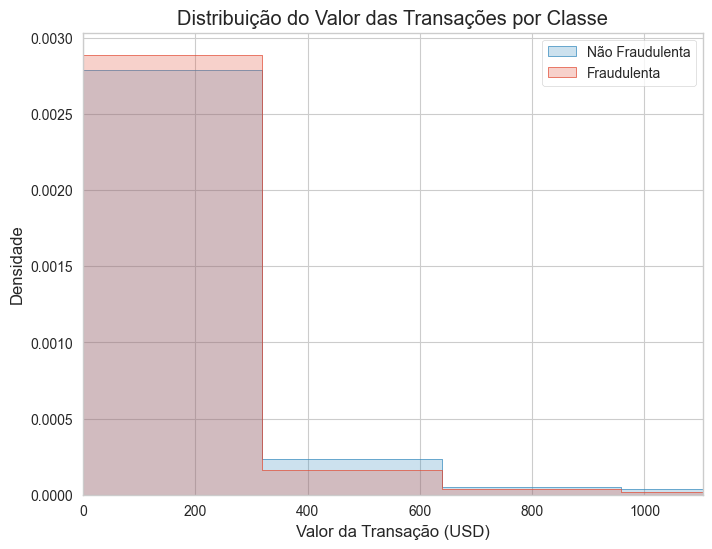

In [38]:
# Comparando a distribuição do valor das transações entre transações fraudulentas e não fraudulentas
plt.figure(figsize=(8, 6))
sns.histplot(data=df_full, x='TransactionAmt', hue='isFraud', bins=100, 
             element='step', stat='density', common_norm=False)
plt.title('Distribuição do Valor das Transações por Classe')
plt.xlabel('Valor da Transação (USD)')
plt.ylabel('Densidade')
plt.xlim(0, df_full['TransactionAmt'].quantile(0.99))  # Limitando para melhor visualização
plt.legend(['Não Fraudulenta', 'Fraudulenta'])
plt.show()

In [45]:
# Visualizando a relação entre o valor da transação e a probabilidade de fraude usando Plotly

df_full['AmtBin'] = pd.qcut(df_full['TransactionAmt'], q=20, duplicates='drop')
fraud_by_amt = df_full.groupby('AmtBin')['isFraud'].agg(['count', 'sum', 'mean'])
fraud_by_amt.columns = ['total_transactions', 'total_frauds', 'fraud_rate']
fraud_by_amt['bin_start'] = fraud_by_amt.index.map(lambda x: x.left)
fraud_by_amt['bin_end'] = fraud_by_amt.index.map(lambda x: x.right)
fraud_by_amt['bin_label'] = fraud_by_amt.apply(lambda x: f'{x["bin_start"]:.2f}-{x["bin_end"]:.2f}', axis=1)

fig = make_subplots(rows=1, cols=1,
                    specs=[[{"secondary_y": True}]], 
                    subplot_titles=['Transações e Taxa de Fraude por Faixa de Valor'])


fig.add_trace(
    go.Bar(x=fraud_by_amt['bin_label'], y=fraud_by_amt['total_transactions'], 
           name='Total de Transações', marker_color='rgb(100, 149, 237)'),
    row=1, col=1, secondary_y=False
)


fig.add_trace(
    go.Scatter(x=fraud_by_amt['bin_label'], y=fraud_by_amt['fraud_rate'] * 100, 
               mode='lines+markers', name='Taxa de Fraude (%)',
               line=dict(color='crimson', width=3)),
    row=1, col=1, secondary_y=True
)


fig.update_layout(
    height=600,
    title='Análise de Fraudes por Faixa de Valor da Transação',
    xaxis_tickangle=45,
    showlegend=True
)


fig.update_xaxes(title_text='Faixa de Valor da Transação (USD)', tickangle=45)
fig.update_yaxes(title_text='Número de Transações', secondary_y=False)
fig.update_yaxes(title_text='Taxa de Fraude (%)', secondary_y=True)

fig.show()

In [46]:
# Selecionando apenas colunas numéricas para análise de correlação
numeric_cols = df_full.select_dtypes(include=['int64', 'float64']).columns.tolist()
cols_to_remove = ['TransactionID', 'TransactionDT', 'TransactionDay', 'TransactionHour']
numeric_cols = [col for col in numeric_cols if col not in cols_to_remove]



# Visualizando a correlação com a variável alvo (isFraud)
corr_matrix = df_full[numeric_cols].corr()
target_corr = corr_matrix['isFraud'].sort_values(ascending=False)
print('Top 20 features com maior correlação positiva com isFraud:')
print(target_corr[1:21])  # Excluindo a própria variável isFraud
print('\nTop 20 features com maior correlação negativa com isFraud:')
print(target_corr[-20:])

Top 20 features com maior correlação positiva com isFraud:
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
Name: isFraud, dtype: float64

Top 20 features com maior correlação negativa com isFraud:
D4      -0.067216
V36     -0.069875
V11     -0.071950
D10     -0.072002
V10     -0.074658
V35     -0.077116
D15     -0.077519
D2      -0.083583
id_07   -0.084768
V70     -0.100900
V30     -0.103088
V69     -0.104521
V91     -0.105453
V29     -0.107852
V90     -0.110168
V49     -0.110920
V48     -0.115786
id_01   -0.120099
D7      -0.127199
D8      -0.142636
Name: isFraud, dtype: float64


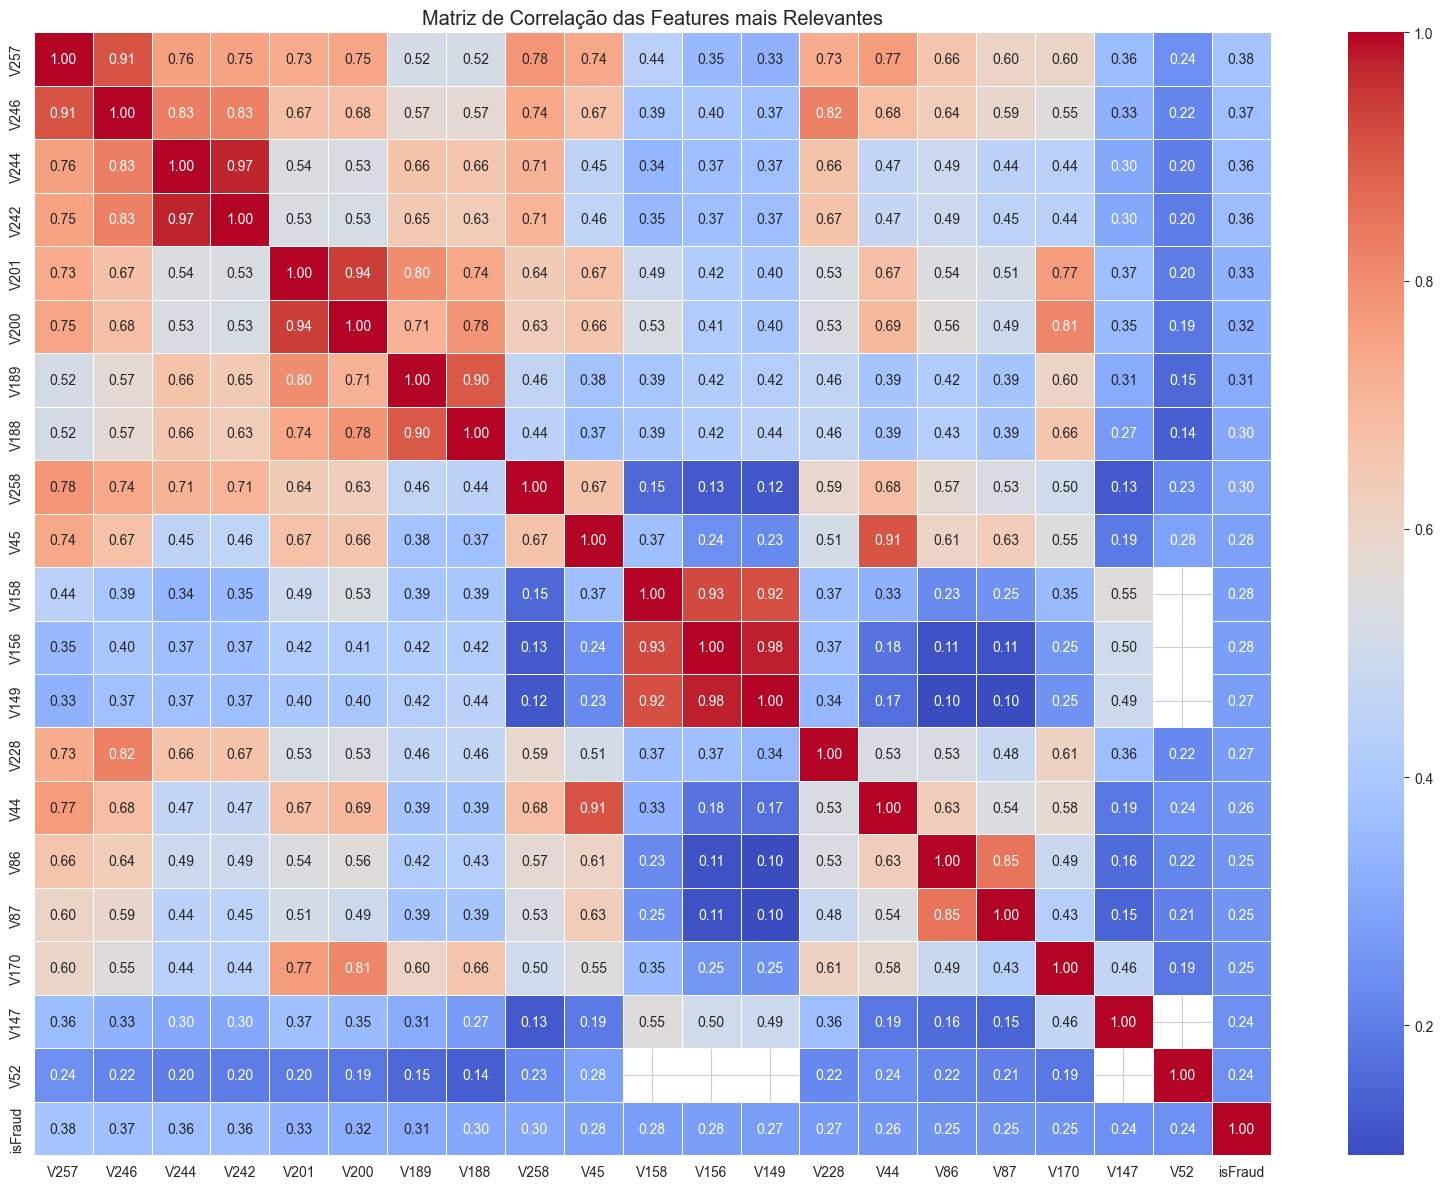

In [47]:
# Visualizando a matriz de correlação
# Selecionando as 20 features mais correlacionadas com isFraud
top_corr_features = target_corr.abs().sort_values(ascending=False)[1:21].index.tolist()
top_corr_features.append('isFraud')  # Adicionando a variável alvo

# Criando a matriz de correlação para as features selecionadas
plt.figure(figsize=(16, 12))
sns.heatmap(df_full[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação das Features mais Relevantes')
plt.tight_layout()
plt.show()

In [ ]:
# Identificando colunas categóricas
categorical_cols = df_full.select_dtypes(include=['object']).columns.tolist()
print(f'colunas categoricas: {categorical_cols}')

Colunas categóricas: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


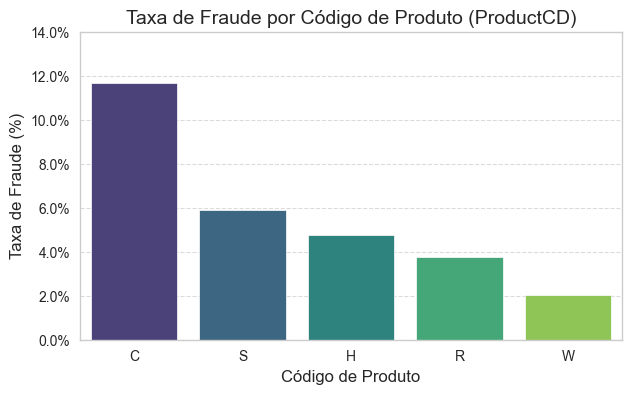

In [53]:
# Analisando a distribuição de produto e sua relação com fraudes
product_fraud = df_full.groupby('ProductCD')['isFraud'].agg(['count', 'sum', 'mean']).reset_index()
product_fraud.columns = ['ProductCD', 'Total de Transações', 'Total de Fraudes', 'Taxa de Fraude']
product_fraud = product_fraud.sort_values('Taxa de Fraude', ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=product_fraud, x='ProductCD', y='Taxa de Fraude', palette='viridis')
plt.title('Taxa de Fraude por Código de Produto (ProductCD)', fontsize=14)
plt.xlabel('Código de Produto')
plt.ylabel('Taxa de Fraude (%)')
plt.ylim(0, product_fraud['Taxa de Fraude'].max() * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.1f}%')) 
plt.show()

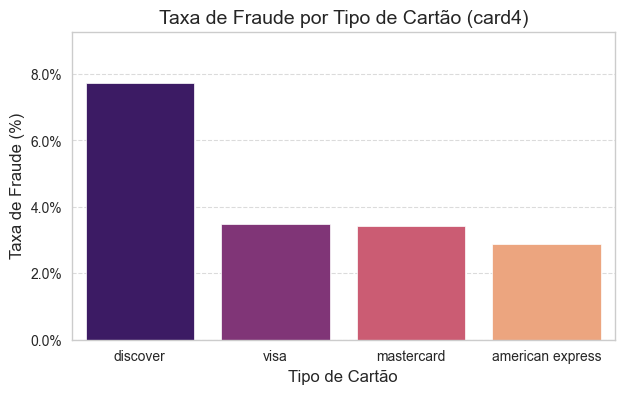

In [60]:
# Analisando a taxa de fraude por tipo de cartão (card4)
card_fraud = df_full.groupby('card4')['isFraud'].agg(['count', 'sum', 'mean']).reset_index()
card_fraud.columns = ['Tipo de Cartão', 'Total de Transações', 'Total de Fraudes', 'Taxa de Fraude']
card_fraud = card_fraud.sort_values('Taxa de Fraude', ascending=False)

# Visualização aprimorada
plt.figure(figsize=(7, 4))
sns.barplot(data=card_fraud, x='Tipo de Cartão', y='Taxa de Fraude', palette='magma')
plt.title('Taxa de Fraude por Tipo de Cartão (card4)', fontsize=14)
plt.xlabel('Tipo de Cartão')
plt.ylabel('Taxa de Fraude (%)')
plt.ylim(0, card_fraud['Taxa de Fraude'].max() * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.1f}%')) 
plt.show()

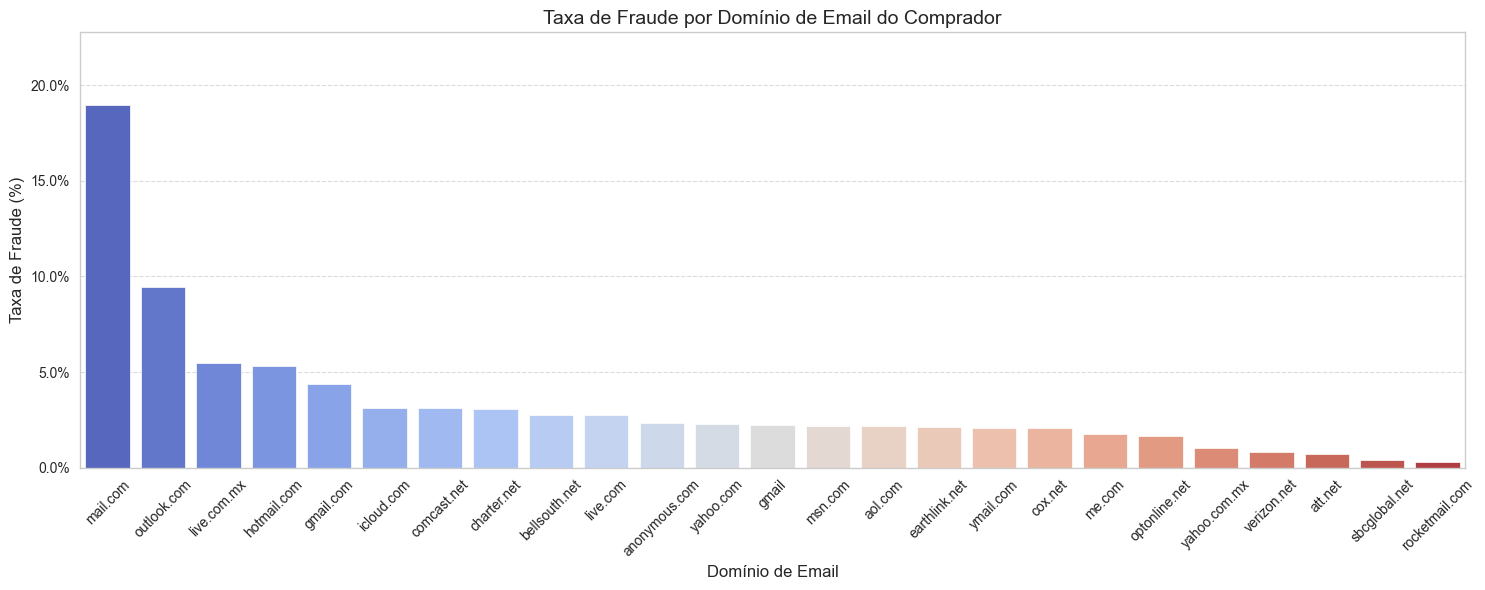

In [76]:
# Pegando os 25 domínios de email mais comuns
top_domains = df_full['P_emaildomain'].value_counts().head(25).index.tolist()

# Calculando métricas de fraude por domínio
email_fraud = df_full[df_full['P_emaildomain'].isin(top_domains)] \
    .groupby('P_emaildomain')['isFraud'] \
    .agg(['count', 'sum', 'mean']) \
    .rename(columns={'count': 'Total de Transações', 'sum': 'Total de Fraudes', 'mean': 'Taxa de Fraude'}) \
    .sort_values('Taxa de Fraude', ascending=False) \
    .reset_index()

# Visualização aprimorada
plt.figure(figsize=(15, 6))
sns.barplot(data=email_fraud, x='P_emaildomain', y='Taxa de Fraude', palette='coolwarm')
plt.title('Taxa de Fraude por Domínio de Email do Comprador', fontsize=14)
plt.xlabel('Domínio de Email')
plt.ylabel('Taxa de Fraude (%)')
plt.xticks(rotation=45)
plt.ylim(0, email_fraud['Taxa de Fraude'].max() * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.1f}%'))  # Exibe % no eixo Y
plt.tight_layout()
plt.show()


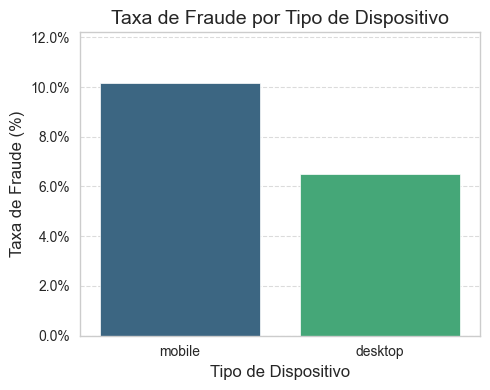

In [ ]:
# Analisando a distribuição de DeviceType e sua relação com fraudes
device_fraud = df_full.groupby('DeviceType')['isFraud'].agg(['count', 'sum', 'mean'])
device_fraud.columns = ['Total de Transações', 'Total de Fraudes', 'Taxa de Fraude']
device_fraud = device_fraud.sort_values('Taxa de Fraude', ascending=False).reset_index()

plt.figure(figsize=(5, 4))
sns.barplot(data=device_fraud, x='DeviceType', y='Taxa de Fraude', palette='viridis')
plt.title('Taxa de Fraude por Tipo de Dispositivo', fontsize=14)
plt.xlabel('Tipo de Dispositivo')
plt.ylabel('Taxa de Fraude (%)')
plt.ylim(0, device_fraud['Taxa de Fraude'].max() * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.1f}%'))
plt.tight_layout()
plt.show()

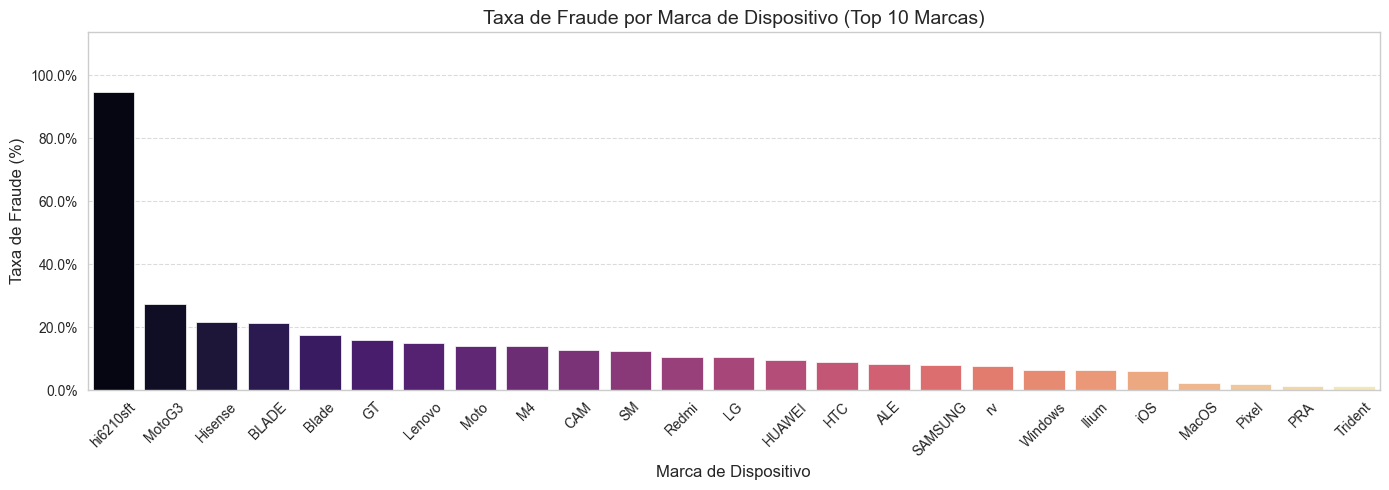

In [75]:
# Extraindo a marca do dispositivo (primeiro termo antes de espaço ou caractere especial)
df_full['DeviceBrand'] = df_full['DeviceInfo'].str.extract(r'^([^\s/:;\-_,\.\\]+)', expand=False)

# Pegando as 10 marcas mais comuns
top_brands = df_full['DeviceBrand'].value_counts().head(25).index.tolist()

# Agrupando e calculando as métricas de fraude
brand_fraud = df_full[df_full['DeviceBrand'].isin(top_brands)].groupby('DeviceBrand')['isFraud'].agg(['count', 'sum', 'mean'])
brand_fraud.columns = ['Total de Transações', 'Total de Fraudes', 'Taxa de Fraude']
brand_fraud = brand_fraud.sort_values('Taxa de Fraude', ascending=False).reset_index()

plt.figure(figsize=(14, 5))
sns.barplot(data=brand_fraud, x='DeviceBrand', y='Taxa de Fraude', palette='magma')
plt.title('Taxa de Fraude por Marca de Dispositivo (Top 10 Marcas)', fontsize=14)
plt.xlabel('Marca de Dispositivo')
plt.ylabel('Taxa de Fraude (%)')
plt.ylim(0, brand_fraud['Taxa de Fraude'].max() * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.1f}%'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Conclusões da Análise Exploratória

Nesta análise exploratória, identificamos vários insights importantes sobre os dados do IEEE-CIS Fraud Detection:

1. **Desbalanceamento de Classes**: Confirmamos o desbalanceamento extremo mencionado na descrição do desafio, com apenas cerca de 3,5% das transações sendo fraudulentas.

2. **Valores Ausentes**: Muitas colunas possuem valores ausentes, especialmente nas features de identidade, o que exigirá estratégias adequadas de tratamento.

3. **Padrões Temporais**: Identificamos padrões na distribuição de fraudes ao longo do tempo, com algumas horas do dia apresentando taxas de fraude significativamente mais altas.

4. **Valor das Transações**: Observamos diferenças na distribuição do valor das transações entre transações fraudulentas e não fraudulentas, com algumas faixas de valor apresentando taxas de fraude mais elevadas.

5. **Features Categóricas**: Algumas categorias específicas em features como ProductCD, tipo de cartão e domínio de email apresentam taxas de fraude significativamente diferentes da média.

6. **Dispositivos**: O tipo e a marca do dispositivo usado na transação também mostram correlação com a probabilidade de fraude.